# Hybrid Family

## Introduction

In this notebook we introduce a family of algorthims applicable to Random Access Code problems where players have access to no-signalling resources. 

Sections:
- PR-Assisted Random Access Codes: An Introduction to RAC's and PR-Assisted RAC's
- Hybrid Majority–Pyramid family: An Introduction to the hybrid algorithm family
- Literature: A short list of key references to literature on the topic

https://github.com/robhendrik/SSF

## PR-Assisted Random Access Codes

A **Random Access Code (RAC)** is a fundamental communication primitive in quantum information theory. In its basic form, Alice holds an $n$-bit string and is permitted to send only a single classical bit $m$ to Bob, who must recover any one bit of Alice's string of his choosing. Since Alice does not know in advance which bit Bob will request, and Bob receives only one bit of information, perfect recovery is impossible classically. The best classical strategy — majority-encoding with identity-decoding — achieves a success probability strictly below 1 for $n > 1$. RACs have found broad application in quantum cryptography, dimension witnessing, semi-device-independent protocols, and as the basis for the information causality principle.

An **Entanglement-Assisted RAC (EARAC)** augments the basic setting by allowing Alice and Bob to share one or more entangled quantum states — typically two-qubit singlets — prior to the protocol, while the message $m$ remains a single classical bit. Alice performs a measurement on her half of the shared state, and the outcome influences the classical bit she sends. Bob then measures his half of the entangled state, guided by the received bit and his choice of index $j$, to produce his guess. Pawłowski and Żukowski (2010) showed that two primitive EARACs exist — encoding 2 and 3 bits respectively into a single classical bit using one shared singlet — and that these can be concatenated to produce an $(n,1)$ EARAC for any $n$, outperforming the best known quantum RACs for $n > 3$ and saturating the upper bound $p_n = \frac{1}{2}(1 + \frac{1}{\sqrt{n}})$ for infinitely many values of $n$.

A **PR-Assisted RAC** replaces the entangled quantum state with a Popescu–Rohrlich (PR) box — a hypothetical maximally nonlocal no-signaling resource — as the pre-shared correlation. As in the EARAC setting, the message is a single classical bit, but the non-local resource is now supra-quantum: a PR box produces perfectly correlated outputs satisfying $o_A \oplus o_B = a \land b$, which no quantum state can reproduce. Grudka et al. (2014) established that a PR box and a $(2 \to 1)$ RAC are strictly equivalent under the no-signaling condition, meaning a PR box supplemented with one classical bit wins a $(2 \to 1)$ RAC with certainty. Chaturvedi et al. (2016) generalised this result, proving that exactly $n-1$ PR boxes are both necessary and sufficient to win a perfect $(n \to 1)$ RAC, establishing a tight resource count for the PR-assisted setting.

## Hybrid Majority–Pyramid family

The Hybrid Majority–Pyramid family is a collection of algorithms for the PR-assisted Random Access Code (RAC) problem, in which Alice holds an $L$-bit input string and must communicate a single bit $c$ to Bob, who must guess any one bit $x_j$ of her input. Alice and Bob may share PR boxes as a pre-distributed non-local resource.

The family interpolates between two pure strategies that represent opposite extremes. In the **pure majority** strategy, Alice sends the majority bit of her input and uses no PR boxes; this works well on skewed inputs but fails when the input is balanced. In the **pure pyramid** strategy, Alice uses $L-1$ PR boxes arranged in a binary tree to compress her input to a single bit; this succeeds on any input but degrades gracefully as PR-box quality $p_\text{rule}$ falls below 1.

The hybrid algorithms trade off these competing strengths along two structural axes. **Horizontal hybrids** switch between strategies adaptively based on the observed input — applying majority when the input is sufficiently skewed and falling back to the pyramid otherwise. **Vertical hybrids** compose the two strategies structurally: the **pyr/maj** variant applies a partial pyramid first and then takes majority over the resulting apex bits, while the **maj/pyr** variant partitions the input into blocks, applies majority within each block, and then runs a short pyramid over the block-level majority outputs.

All schemes share a common XOR-based success structure: Bob's guess is always $\hat{x}_j = c \oplus f_B(j)$, so errors in the communication bit and in Bob's flip function cancel, giving a double-error compensation property. The overall success probability is governed by $P_\text{success} = \frac{1}{2} + (P_C - \frac{1}{2})(2P_P - 1)$, where $P_C$ and $P_P$ are the correctness probabilities of the communication and flip sub-schemes respectively, making clear that both components must individually beat chance for the hybrid to outperform either pure baseline.

TODO: Add reference to hybrid family markdown

## Literature

---

**[1]** Popescu, S. & Rohrlich, D. (1994). "Quantum nonlocality as an axiom." *Foundations of Physics*, 24(3), 379–385.

*Introduces the PR box as the maximally nonlocal no-signaling resource, the foundational object in all PR-assisted RAC work.*

---

**[2]** Pawłowski, M., Paterek, T., Kaszlikowski, D., Scarani, V., Winter, A. & Żukowski, M. (2009). "Information causality as a physical principle." *Nature*, 461, 1101–1104.

*Uses the PR-box/RAC connection to formulate information causality, establishing the information-theoretic significance of PR-assisted RACs.*

---

**[3]** Pawłowski, M. & Żukowski, M. (2010). "Entanglement-assisted random access codes." *Physical Review A*, 81(4), 042326.

*Introduces EARACs using pre-shared entangled singlets with classical communication, a closely related but distinct resource setting to PR-assisted RACs.*

---

**[4]** Grudka, A., Horodecki, K., Horodecki, M., Kłobus, W. & Pawłowski, M. (2014). "When are Popescu-Rohrlich boxes and random access codes equivalent?" *Physical Review Letters*, 113(10), 100401.

*The canonical reference: proves that a no-signaling RAC box supplemented with one bit of communication is strictly equivalent to a PR box.*

---

**[5]** Grudka, A., Horodecki, M., Horodecki, R. & Wójcik, A. (2015). "Nonsignaling quantum random access code boxes." *Physical Review A*, 92(5), 052312.

*Extends the PR-RAC framework to quantum inputs and outputs, proposing a quantum analogue of the racbox.*

---

**[6]** Chaturvedi, A., Pawłowski, M. & Horodecki, K. (2016). "Random access codes and non-local resources." *arXiv:1610.01268*.

*Generalizes the PR-RAC equivalence to n bits, proving that exactly n−1 PR boxes are necessary and sufficient to win a perfect (n→1) RAC with one classical bit.*

---

**[7]** Doriguello, J.F. & Montanaro, A. (2021). "Quantum random access codes for Boolean functions." *Quantum*, 5, 402.

*Introduces f-PRRACs, extending PR-assisted RACs to the recovery of Boolean functions, with success probability characterized by noise stability.*

---

**[8]** Ambainis, A., Kravchenko, D., Sazim, S., Bae, J. & Rai, A. (2024). "Quantum advantages in (n,d)→1 random access codes." *New Journal of Physics*, 26, 123023.

*Characterizes optimal classical RAC strategies and demonstrates quantum advantage via incompatible measurements; provides the classical benchmark against which PR-assisted performance can be compared.*

---

**[9]** Farkas, M., Miklin, N. & Tavakoli, A. (2025). "Simple and general bounds on quantum random access codes." *Quantum*, 9, 1643.

*Derives universal analytic upper bounds on quantum RAC success probability for general (n,d,D); provides the best known general upper bound framework contextualizing where PR-assisted RACs sit relative to quantum limits.*

## Analytical performance of the Hybrid family
This notebook calls the script `scripts/compare/plot_analytics_family_curves.py` to generate curvesfor the win-rate as a function of the strength of the non-local correlation (defined by $p_{\text{rule}}$)

The `plot_analytics_family_curves.py` is part of the SSF package where optimal performance within the hybrid family is assessed. 

Parameters:
* The length of the bit-string is indicated by $n2$
* The number of PR-boxes available is indicated by $k$
* The range within which we consider the Hamming weight of a (sub)string tied is indicated by $b$
* The sub-family is indicated by `horiz` and `vert`

We call the script via CLI for `n2 = 4, 8, 16`, saves the figures, and then displays them inline.

In [1]:
import subprocess
import sys
from pathlib import Path
from IPython.display import Image, display

In [2]:
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

script_path = project_root / "scripts" / "compare" / "plot_analytics_family_curves.py"
output_dir = project_root / "results" / "analytics_curves"
n2_values = [4, 8, 16]
dpi = 150

if not script_path.exists():
    raise FileNotFoundError(f"Script not found: {script_path}")

output_dir.mkdir(parents=True, exist_ok=True)

print("project_root: .")
print(f"script_path:  {script_path.relative_to(project_root)}")
print(f"output_dir:   {output_dir.relative_to(project_root)}")
print(f"n2_values:    {n2_values}")

project_root: .
script_path:  scripts\compare\plot_analytics_family_curves.py
output_dir:   results\analytics_curves
n2_values:    [4, 8, 16]


In [3]:
script_rel = script_path.relative_to(project_root)
output_rel = output_dir.relative_to(project_root)

cmd = [
    sys.executable,
    str(script_rel),
    "--output-dir",
    str(output_rel),
    "--dpi",
    str(dpi),
    "--n2-values",
    *[str(v) for v in n2_values],
]

display_cmd = [
    "python",
    str(script_rel),
    "--output-dir",
    str(output_rel),
    "--dpi",
    str(dpi),
    "--n2-values",
    *[str(v) for v in n2_values],
]

print("Running:")
print(" ".join(display_cmd))

def _sanitize_paths(text: str) -> str:
    sanitized = text.replace(str(project_root), ".")
    sanitized = sanitized.replace(str(project_root).replace("\\", "/"), ".")
    return sanitized

try:
    completed = subprocess.run(
        cmd,
        cwd=project_root,
        text=True,
        capture_output=True,
        check=True,
    )
except subprocess.CalledProcessError as exc:
    print("\nCLI failed.")
    if exc.stdout and exc.stdout.strip():
        print("\nCLI stdout:")
        print(_sanitize_paths(exc.stdout))
    if exc.stderr and exc.stderr.strip():
        print("\nCLI stderr:")
        print(_sanitize_paths(exc.stderr))
    raise

if completed.stdout.strip():
    print("\nCLI stdout:")
    print(_sanitize_paths(completed.stdout))

if completed.stderr.strip():
    print("\nCLI stderr:")
    print(_sanitize_paths(completed.stderr))

print("Done generating figures.")

Running:
python scripts\compare\plot_analytics_family_curves.py --output-dir results\analytics_curves --dpi 150 --n2-values 4 8 16

CLI stdout:
Generating figure for n2=4 ...
  Saved: results\analytics_curves\analytics_curves_n2_4.png
Generating figure for n2=8 ...
  Saved: results\analytics_curves\analytics_curves_n2_8.png
Generating figure for n2=16 ...
  Saved: results\analytics_curves\analytics_curves_n2_16.png
Done.

Done generating figures.


n2=4: results\analytics_curves\analytics_curves_n2_4.png


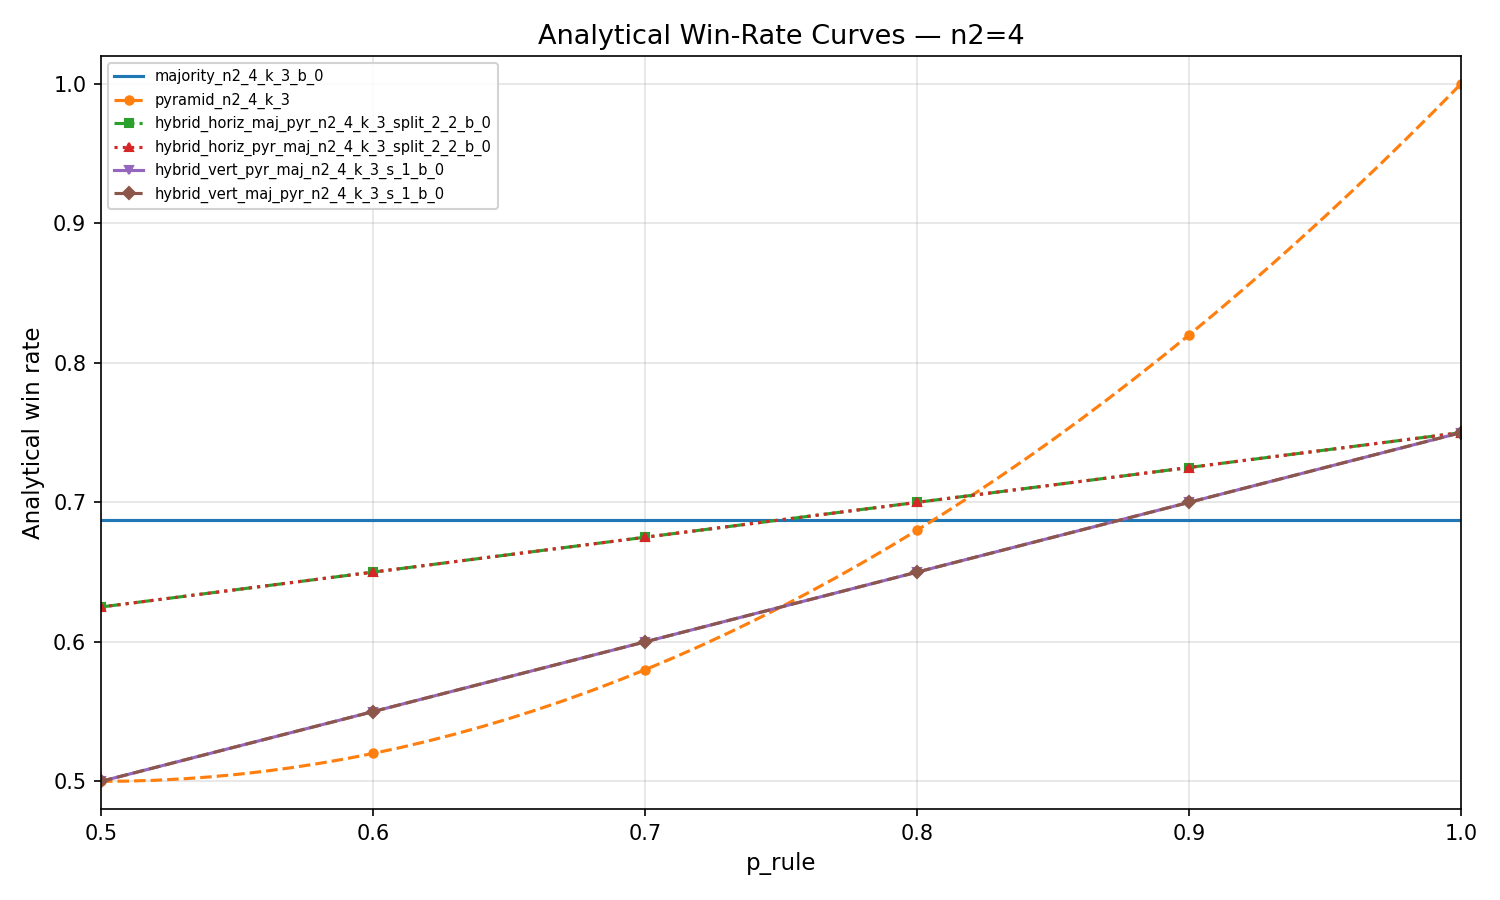

n2=8: results\analytics_curves\analytics_curves_n2_8.png


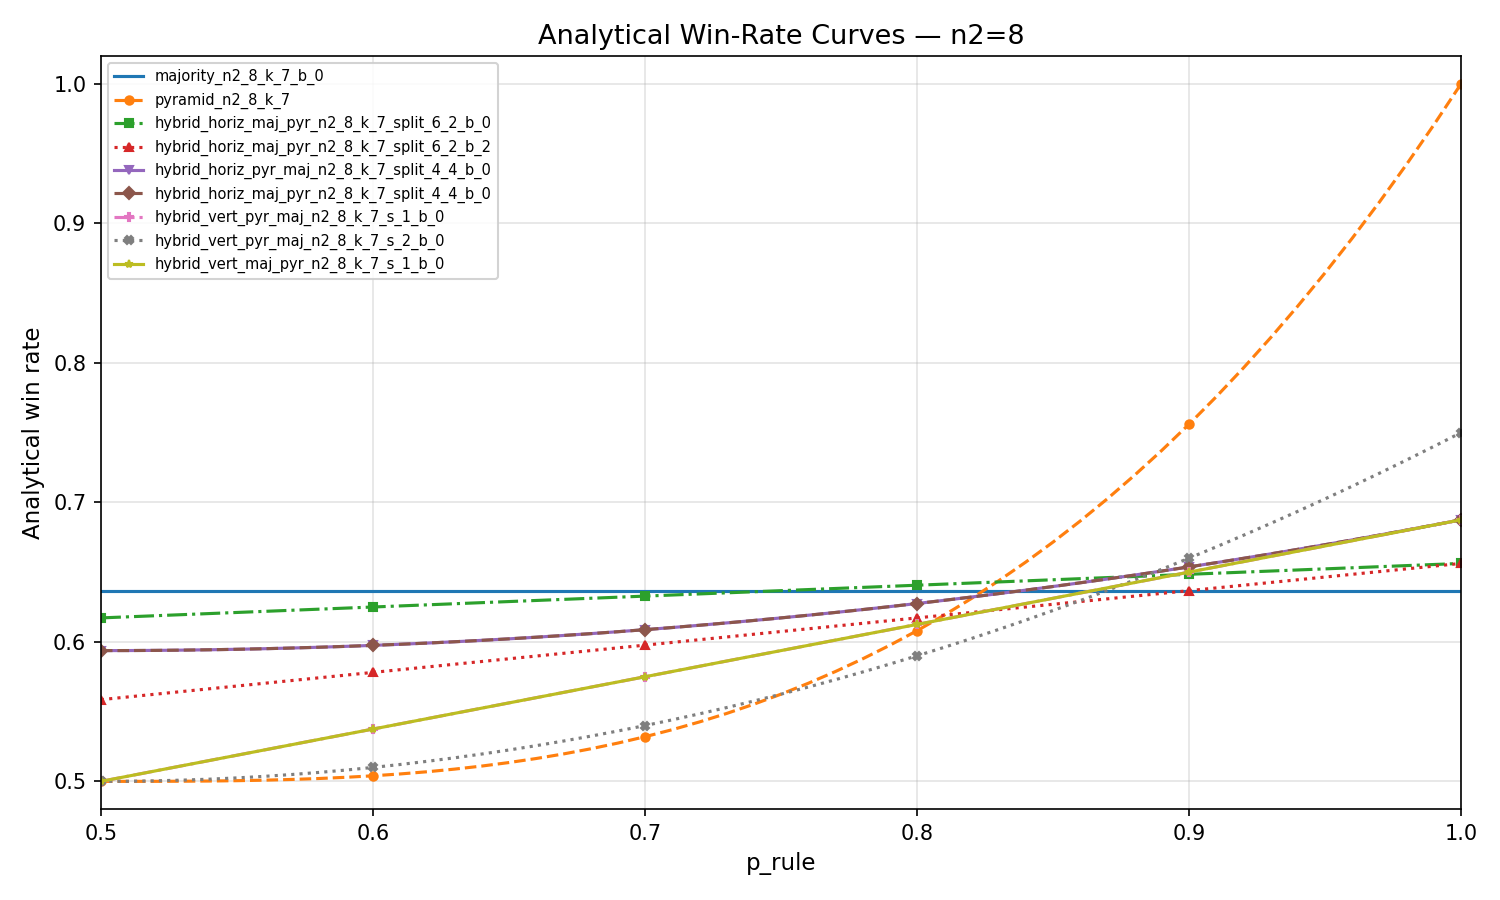

n2=16: results\analytics_curves\analytics_curves_n2_16.png


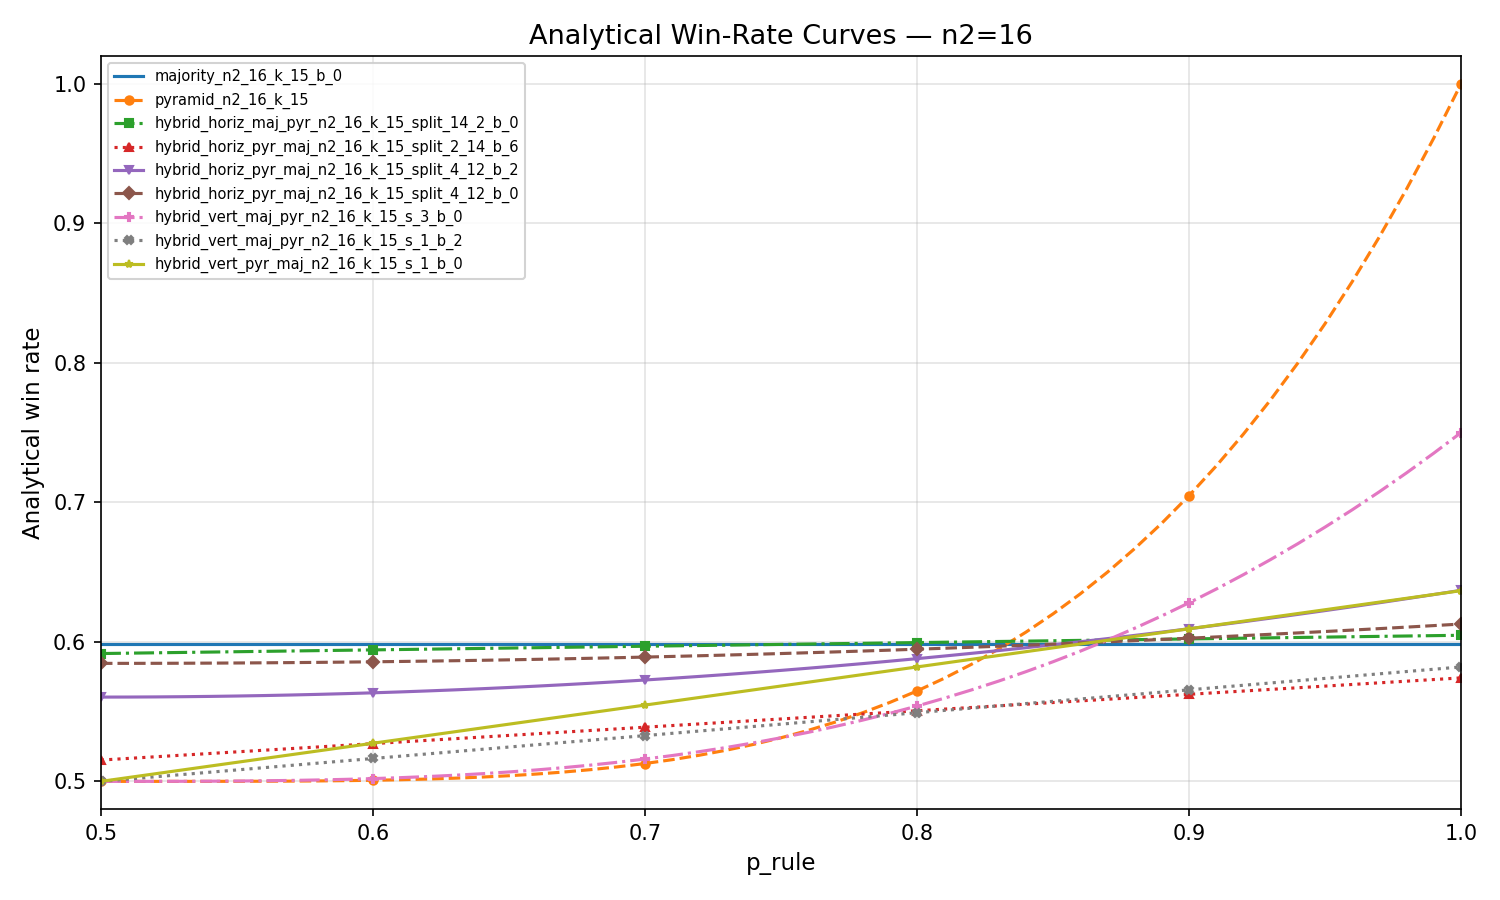

In [4]:
for n2 in n2_values:
    png_path = output_dir / f"analytics_curves_n2_{n2}.png"
    print(f"n2={n2}: {png_path.relative_to(project_root)}")
    if not png_path.exists():
        print("  Missing image file; run the CLI cell above first.")
        continue

    display(Image(filename=str(png_path)))

## Reference

- Author: Rob Hendriks
- Copyright: © 2026 SSF contributors
- GitHub: https://github.com/robhendrik/SSF